## Import TensorFlow and other libraries

In [1]:
import tensorflow as tf
import tensorflow_io as tfio
import tensorflow_addons as tfa
import tensorflow.compat.v1 as tf1

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2
from itertools import combinations

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed
import face_recognition
import random
from scipy.interpolate import LinearNDInterpolator
from scipy import stats

import mediapipe as mp
from fid import get_frechet_inception_distance
import frechet_video_distance as fvd

2023-05-26 17:25:37.024695: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-26 17:25:37.074816: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow com

In [2]:
COHERENCE_LOSS = None
MAIN_LOSS = "l1"
LANDMARKS_LOSS = None
LANDMARKS_COHERENCE_LOSS = None

# Dimensions
r = 128
BATCH_SIZE = 64
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68


STEPS = 100000
STEPS = STEPS // BATCH_SIZE

LAMBDA1 = 1000
LAMBDA2 = 200
LAMBDA3 = 1000
LAMBDA4 = 200

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'

## Load the dataset

In [3]:
videos_path = list((DATA_PATH / VIDEOS_FOLDER).glob('**/*.npy'))

In [4]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [5]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

## Build an input pipeline with `tf.keras.utils.Sequence`

In [6]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

tf.print(len(train_paths))
tf.print(len(test_paths))

723
310


2023-05-26 17:25:43.017632: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14112 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


In [7]:
class FrameDataGenerator():
    
    def __init__(self, videos_path, batch_size=1):
        self.videos_path = videos_path
        self.n = len(videos_path)
        self._restart()
        self.batch_size = batch_size
    
    def _load_current_video(self):
        self.current_video = np.load(self.videos_path[self.current_video_index])
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        self.current_video_index += 1
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    

    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+1]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-1]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+1 < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+1 < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self): # TODO: fix to consider batch size
        self.current_frame_index += 1 # Frame index start at one because we have to return the previous frame
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()

In [8]:
train_generator = FrameDataGenerator(train_paths, batch_size=BATCH_SIZE)
test_generator = FrameDataGenerator(test_paths, batch_size=BATCH_SIZE)

previous_frame, current_frame, next_frame = next(test_generator)
tf.print(previous_frame.shape)
tf.print(current_frame.shape)
tf.print(next_frame.shape)

(64, 128, 128, 3)
(64, 128, 128, 3)
(64, 128, 128, 3)


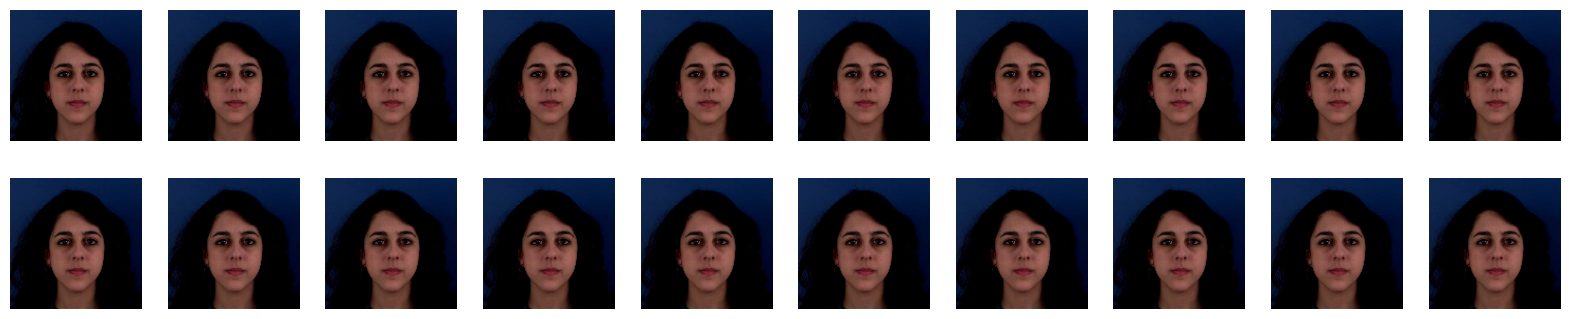

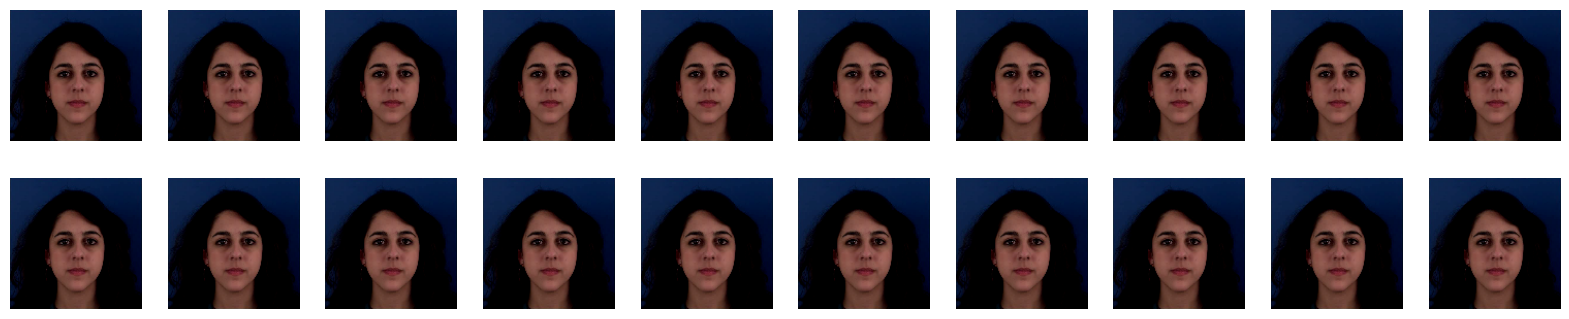

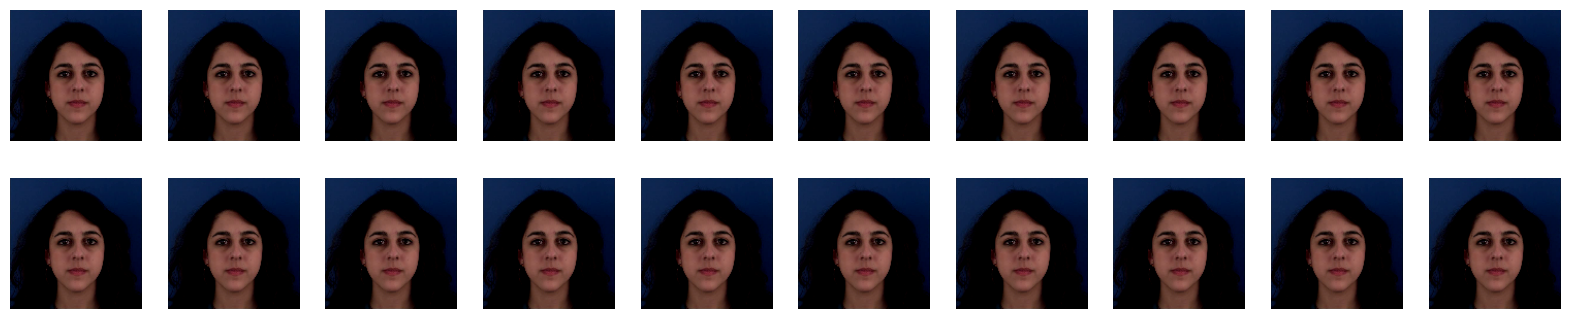

In [9]:
plot_normalized_sequence(previous_frame)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)

In [10]:
unormalize_target_sequence = normalized_sequence_to_images(current_frame)
unormalize_generated_output = normalized_sequence_to_images(next_frame)

In [11]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [12]:
# scale an array of images to a new size
# def scale_images(images, new_shape):
#  images_list = list()
#  for image in images:
#  # resize with nearest neighbor interpolation
#  new_image = resize(image, new_shape, 0)
#  # store
#  images_list.append(new_image)
#  return asarray(images_list)
# inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(IMG_WIDTH,IMG_HEIGHT,3))

# # calculate frechet inception distance
# def calculate_fid(inception_model, target_sequence, generated_output):
#     target_sequence = target_sequence.astype('float32')
#     generated_output = generated_output.astype('float32')
#     # calculate activations
#     act1 = inception_model.predict(target_sequence)
#     act2 = inception_model.predict(generated_output)
#     # calculate mean and covariance statistics
#     mu1, sigma1 = act1.mean(axis=0), cov(act1, rowvar=False)
#     mu2, sigma2 = act2.mean(axis=0), cov(act2, rowvar=False)
#     # calculate sum squared difference between means
#     ssdiff = np.sum((mu1 - mu2)**2.0)
#     # calculate sqrt of product between cov
#     covmean = sqrtm(sigma1.dot(sigma2))
#     # check and correct imaginary numbers from sqrt
#     if iscomplexobj(covmean):
#         covmean = covmean.real
#     # calculate score
#     fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
#     return fid

In [13]:
# get_frechet_inception_distance(unormalize_target_sequence, unormalize_generated_output, batch_size=BATCH_SIZE, num_inception_images=BATCH_SIZE)

In [14]:
# compare_acd(unormalize_target_sequence, unormalize_generated_output)

In [15]:
# import tensorflow_hub as hub

# @tf.function
# def test():
#     first_set_of_videos = tf.zeros([16, 15, 64, 64, 3])

#     module_spec = "https://tfhub.dev/deepmind/i3d-kinetics-400/1"


#   # Making sure that we import the graph separately for
#   # each different input video tensor.
#   module_name = "fvd_kinetics-400_id3_module_" + six.ensure_str(
#       videos.name).replace(":", "_")

#     module_scope = "%s_apply_default/" % module_name

#     tensor_name = module_scope + "RGB/inception_i3d/Mean:0"

#     i3d_model = hub.Module(module_spec, name=module_name)
#     logits = i3d_model(first_set_of_videos)
#     return logits
# print(test().shape)

In [16]:
import frechet_video_distance as fvd

@tf.function
def get_id3_embedding(videos_sequences):
    pre_processed = fvd.preprocess(videos_sequences, (224, 224))
    return fvd.create_id3_embedding(pre_processed)

@tf.function
def get_fvd(target_sequence, generated_output):
  # tf1.disable_v2_behavior()
  # with tf1.Graph().as_default():
    target_embedding = get_id3_embedding(target_sequence)
    generated_embedding = get_id3_embedding(generated_output)
    result = fvd.calculate_fvd(generated_embedding,target_embedding)
    # with tf1.Session() as sess:
    #   sess.run(tf1.global_variables_initializer())
    #   sess.run(tf1.tables_initializer())
    #   return sess.run(result)
    return result

In [17]:

current_videos = []
next_videos = []
for i in range(16):
    previous_frame, current_frame, next_frame = next(test_generator)
    unormalize_target_sequence = normalized_sequence_to_images(current_frame)
    unormalize_generated_output = normalized_sequence_to_images(next_frame)
    current_videos.append(unormalize_target_sequence)
    next_videos.append(unormalize_generated_output)
current_videos = tf.stack(current_videos)
next_videos = tf.stack(next_videos)
tf.print(current_videos.shape)
tf.print(next_videos.shape)
get_fvd(current_videos, next_videos)

TensorShape([16, 64, 128, 128, 3])
TensorShape([16, 64, 128, 128, 3])


TypeError: in user code:

    File "/tmp/ipykernel_34550/2311523206.py", line 14, in get_fvd  *
        result = fvd.calculate_fvd(generated_embedding,target_embedding)
    File "/home/jupyter/app/frechet_video_distance.py", line 149, in calculate_fvd  *
        real_activations, generated_activations)
    File "/usr/local/lib/python3.8/dist-packages/tensorflow_gan/python/eval/classifier_metrics.py", line 793, in frechet_classifier_distance_from_activations  *
        activations1, activations2, streaming=False)
    File "/usr/local/lib/python3.8/dist-packages/tensorflow_gan/python/eval/classifier_metrics.py", line 692, in _frechet_classifier_distance_from_activations_helper  *
        activations1 = tf.convert_to_tensor(value=activations1)

    TypeError: can't convert Operation 'StatefulPartitionedCall_1' to Tensor


In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(target_sequence, generated_output, batch_size=BATCH_SIZE):
    unormalize_target_sequence = normalized_sequence_to_images(target_sequence)
    unormalize_generated_output = normalized_sequence_to_images(generated_output)
    #cast to float32
    # target_sequence = tf.cast(target_sequence, tf.float32)
    # generated_output = tf.cast(generated_output, tf.float32)
    #compute ssim
    ssim_score = tf.image.ssim(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute psnr
    psnr_score = tf.image.psnr(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute mse
    mse_score = tf.keras.losses.MSE(unormalize_target_sequence, unormalize_generated_output)
    #compute l1
    l1_score = tf.keras.losses.MAE(unormalize_target_sequence, unormalize_generated_output)
    # compute fid
    fid_scores = get_frechet_inception_distance(unormalize_target_sequence, unormalize_generated_output, batch_size=batch_size, num_inception_images=batch_size)
    # compute fvd
    # fvd_scores = calculate_fvd(unormalize_target_sequence, unormalize_generated_output)
    # compute acd
    acd_scores = compare_acd(unormalize_target_sequence, unormalize_generated_output)
    return  {
        "SSIM": ssim_scores,
        "PSNR": psnr_scores,
        "MSE": mse_scores,
        "L1": l1_scores,
        "ACD": acd_scores,
        # "FVD": fvd_scores

test_generator = FrameDataGenerator(test_paths)
test_frames = np.array(list(test_generator))

batch = 1000
for i in tqdm(range(0, len(test_frames), batch)):
  input_frames = test_frames[i:i+batch,1,:,:,:]
  target_frames = test_frames[i:i+batch,2,0,:,:]
  predicted_frames = np.array([generator(f, training=False) for f in input_frames])[:,0,...]
  scores.append(evaluate_metrics(target_frames, predicted_frames, batch_size=batch))

scores = []

test_generator = FrameDataGenerator(test_paths)
test_frames = np.array(list(test_generator))

batch = 1000
for i in tqdm(range(0, len(test_frames), batch)):
  input_frames = test_frames[i:i+batch,1,:,:,:]
  target_frames = test_frames[i:i+batch,2,0,:,:]
  predicted_frames = np.array([generator(f, training=False) for f in input_frames])[:,0,...]
  scores.append(evaluate_metrics(target_frames, predicted_frames, batch_size=batch))

In [ ]:
scores = {
    "SSIM": ssim_scores,
    "PSNR": psnr_scores,
    "MSE": mse_scores,
    "L1": l1_scores,
}

score_string = ""
for score_name in scores.keys():
    mean = tf.math.reduce_mean(scores[score_name])
    tf.print(f"{score_name} score: {mean}")
    score_string += f"{mean}\t"

tf.print(score_string)

In [ ]:
train_generator = FrameDataGenerator(train_paths)
train_frames = np.array(list(train_generator))
tf.print(train_frames.shape)

In [ ]:
test_generator = FrameDataGenerator(test_paths)
test_frames = np.array(list(test_generator))
tf.print(test_frames.shape)

## Different order

In [ ]:
new_order = [0, 10, 1, 11, 2, 12, 3, 13, 4, 14, 5, 15, 6, 16, 7, 17, 8, 18, 9]

# # Run the trained model on a few examples from the test set
# for i, (inp, tar) in enumerate(test_dataset.take(5)):
#   inp = tf.gather(inp, new_order, axis=-1)
#   tar = tf.gather(tar, new_order, axis=-1)
#   # inp = inp[..., new_order]
#   # tar = tar[..., new_order]
#   tf.print(i)
#   generate_sequences(generator, inp, tar, save_dir=save_dir)